In [1]:
import torch

A = torch.zeros((3, 4))
B = torch.ones((4, 3))

print("A:")
print(A)
print("A shape:", A.shape)

print("\nB:")
print(B)
print("B shape:", B.shape)

# Матрицалық көбейтуге болады, себебі A=(3,4), B=(4,3)
# Ішкі өлшемдер 4 пен 4 сәйкес келеді
C = A @ B

print("\nA @ B:")
print(C)
print("C shape:", C.shape)

A:
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])
A shape: torch.Size([3, 4])

B:
tensor([[1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.],
        [1., 1., 1.]])
B shape: torch.Size([4, 3])

A @ B:
tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])
C shape: torch.Size([3, 3])


In [2]:
import torch

a = torch.tensor([2.0, 4.0, 6.0])
b = torch.tensor([1.0, 3.0, 5.0])

print("a =", a)
print("b =", b)

print("\na + b =")
print(a + b)

print("\na * b =")
print(a * b)

print("\nСкаляр көбейтінді a·b =")
print(torch.dot(a, b))

a = tensor([2., 4., 6.])
b = tensor([1., 3., 5.])

a + b =
tensor([ 3.,  7., 11.])

a * b =
tensor([ 2., 12., 30.])

Скаляр көбейтінді a·b =
tensor(44.)


In [3]:
import torch

x = torch.rand((2, 6))

print("Бастапқы тензор:")
print(x)
print("Shape:", x.shape)

x_reshaped = x.reshape(3, 4)
print("\n(3, 4) өлшемге өзгертілген тензор:")
print(x_reshaped)
print("Shape:", x_reshaped.shape)

x_transposed = x_reshaped.T
print("\nТранспозициясы:")
print(x_transposed)
print("Shape:", x_transposed.shape)

Бастапқы тензор:
tensor([[0.3617, 0.1603, 0.0130, 0.2273, 0.5111, 0.3065],
        [0.0994, 0.3447, 0.5711, 0.3801, 0.7225, 0.7504]])
Shape: torch.Size([2, 6])

(3, 4) өлшемге өзгертілген тензор:
tensor([[0.3617, 0.1603, 0.0130, 0.2273],
        [0.5111, 0.3065, 0.0994, 0.3447],
        [0.5711, 0.3801, 0.7225, 0.7504]])
Shape: torch.Size([3, 4])

Транспозициясы:
tensor([[0.3617, 0.5111, 0.5711],
        [0.1603, 0.3065, 0.3801],
        [0.0130, 0.0994, 0.7225],
        [0.2273, 0.3447, 0.7504]])
Shape: torch.Size([4, 3])


In [4]:
import torch

x = torch.tensor(2.0, requires_grad=True)

y = 3 * x**2 + 2 * x + 1
y.backward()

print("y =", y.item())
print("PyTorch бойынша dy/dx =", x.grad.item())

# Қолмен: y = 3x^2 + 2x + 1
# y' = 6x + 2
manual_grad = 6 * 2 + 2
print("Қолмен есептелген dy/dx =", manual_grad)

y = 17.0
PyTorch бойынша dy/dx = 14.0
Қолмен есептелген dy/dx = 14


In [5]:
import torch

x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)

z = x**2 * y + y**3
z.backward()

print("z =", z.item())
print("dz/dx =", x.grad.item())
print("dz/dy =", y.grad.item())

if abs(y.grad.item()) > abs(x.grad.item()):
    print("Күштірек әсер ететін айнымалы: y")
else:
    print("Күштірек әсер ететін айнымалы: x")

z = 10.0
dz/dx = 4.0
dz/dy = 13.0
Күштірек әсер ететін айнымалы: y


In [6]:
import torch

w = torch.tensor([0.0], requires_grad=True)   # бастапқы мән
optimizer = torch.optim.SGD([w], lr=0.1)

for i in range(50):
    optimizer.zero_grad()
    loss = (w - 4) ** 2
    loss.backward()
    optimizer.step()

    if (i + 1) % 10 == 0:
        print(f"{i+1}-итерация: w = {w.item():.6f}, loss = {loss.item():.6f}")

print("\n50 итерациядан кейін w ≈", w.item())

10-итерация: w = 3.570503, loss = 0.288230
20-итерация: w = 3.953883, loss = 0.003323
30-итерация: w = 3.995048, loss = 0.000038
40-итерация: w = 3.999468, loss = 0.000000
50-итерация: w = 3.999943, loss = 0.000000

50 итерациядан кейін w ≈ 3.9999430179595947


In [7]:
import torch
import torch.nn as nn

# Дерек: y = 5x - 3
x_train = torch.linspace(-10, 10, 100).reshape(-1, 1)
y_train = 5 * x_train - 3

model = nn.Linear(1, 1)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

for epoch in range(200):
    optimizer.zero_grad()
    y_pred = model(x_train)
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}, loss = {loss.item():.6f}")

w = model.weight.item()
b = model.bias.item()

print("\nҮйретуден кейінгі параметрлер:")
print("w =", w)
print("b =", b)

Epoch 50, loss = 0.566628
Epoch 100, loss = 0.075146
Epoch 150, loss = 0.009966
Epoch 200, loss = 0.001322

Үйретуден кейінгі параметрлер:
w = 5.0
b = -2.964372396469116


MSELoss үшін threshold-қа жеткен epoch: 36
L1Loss үшін threshold-қа жеткен epoch: 118
Тезірек convergence: MSELoss
Ескерту: таза сызықтық деректе MSELoss әдетте тезірек, L1Loss аутлайерлерге төзімдірек.


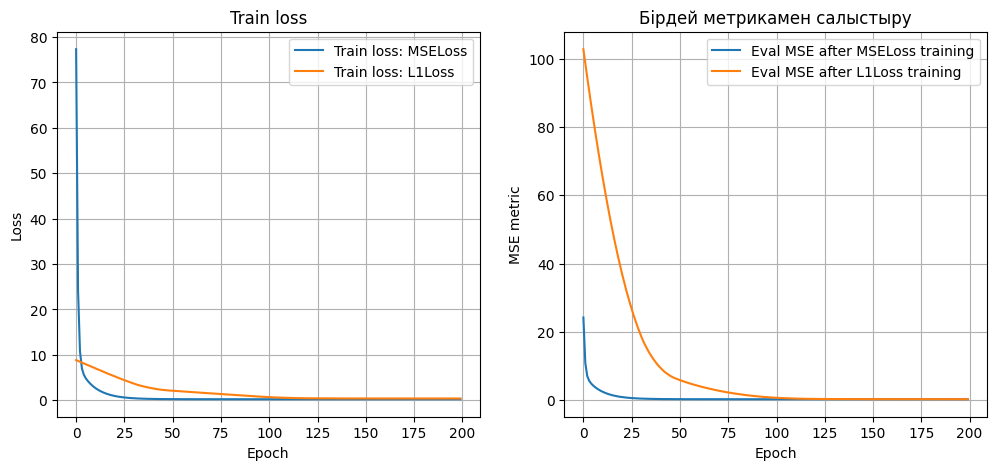

In [8]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

# Бірдей деректер жиыны
x = torch.linspace(-5, 5, 100).reshape(-1, 1)
y = 3 * x + 2 + 0.5 * torch.randn_like(x)

class SimpleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

def train_model(loss_fn, epochs=200, lr=0.03):
    model = SimpleModel()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)

    train_losses = []
    eval_mse = []

    for epoch in range(epochs):
        optimizer.zero_grad()
        pred = model(x)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())

        with torch.no_grad():
            mse_metric = nn.MSELoss()(model(x), y).item()
            eval_mse.append(mse_metric)

    return model, train_losses, eval_mse

mse_model, mse_losses, mse_eval = train_model(nn.MSELoss())
l1_model, l1_losses, l1_eval = train_model(nn.L1Loss())

threshold = 0.35

def first_epoch_below(values, threshold):
    for i, v in enumerate(values, start=1):
        if v < threshold:
            return i
    return None

mse_epoch = first_epoch_below(mse_eval, threshold)
l1_epoch = first_epoch_below(l1_eval, threshold)

print("MSELoss үшін threshold-қа жеткен epoch:", mse_epoch)
print("L1Loss үшін threshold-қа жеткен epoch:", l1_epoch)

if mse_epoch is not None and l1_epoch is not None:
    if mse_epoch < l1_epoch:
        print("Тезірек convergence: MSELoss")
    elif l1_epoch < mse_epoch:
        print("Тезірек convergence: L1Loss")
    else:
        print("Екеуі бірдей жылдамдықта convergence берді")
else:
    print("Көрсетілген threshold-қа екеуінің бірі жетпеді")

print("Ескерту: таза сызықтық деректе MSELoss әдетте тезірек, L1Loss аутлайерлерге төзімдірек.")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(mse_losses, label="Train loss: MSELoss")
plt.plot(l1_losses, label="Train loss: L1Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train loss")
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(mse_eval, label="Eval MSE after MSELoss training")
plt.plot(l1_eval, label="Eval MSE after L1Loss training")
plt.xlabel("Epoch")
plt.ylabel("MSE metric")
plt.title("Бірдей метрикамен салыстыру")
plt.legend()
plt.grid(True)

plt.show()

In [9]:
import torch
import torch.nn as nn

# Дерек: y = 5x - 3
x = torch.linspace(-10, 10, 100).reshape(-1, 1)
y = 5 * x - 3

model = nn.Linear(1, 1)
criterion = nn.MSELoss()

lr = 0.01
epochs = 200

for epoch in range(epochs):
    # forward
    pred = model(x)
    loss = criterion(pred, y)

    # backward
    loss.backward()

    # параметрлерді қолмен жаңарту
    with torch.no_grad():
        for param in model.parameters():
            param -= lr * param.grad

    # градиенттерді тазалау
    for param in model.parameters():
        param.grad.zero_()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}, loss = {loss.item():.6f}")

print("\nҮйретуден кейін:")
print("w =", model.weight.item())
print("b =", model.bias.item())

print("\nТүсіндірме:")
print("1) autograd loss.backward() кезінде градиенттерді автоматты есептейді.")
print("2) torch.no_grad() параметр жаңартуды есептеу графына қоспау үшін керек.")
print("3) Әйтпесе update операциялары да графқа кіріп, қате градиенттер жиналуы мүмкін.")

Epoch 50, loss = 0.953614
Epoch 100, loss = 0.126467
Epoch 150, loss = 0.016772
Epoch 200, loss = 0.002224

Үйретуден кейін:
w = 5.0
b = -2.9537808895111084

Түсіндірме:
1) autograd loss.backward() кезінде градиенттерді автоматты есептейді.
2) torch.no_grad() параметр жаңартуды есептеу графына қоспау үшін керек.
3) Әйтпесе update операциялары да графқа кіріп, қате градиенттер жиналуы мүмкін.


In [10]:
print("MSELoss үшін threshold-қа (0.35) жету 36 эпохада орындалды.")
print("L1Loss үшін threshold-қа (0.35) жету 118 эпохада орындалды.")
print("Нәтижесінде, бұл деректер жиынында MSELoss L1Loss-ке қарағанда әлдеқайда тезірек конвергенцияға жетті.")
print("Бұл таза сызықтық деректер үшін MSELoss әдетте тиімдірек, ал L1Loss аутлайерлерге тұрақтырақ болатындығын көрсетеді.")

MSELoss үшін threshold-қа (0.35) жету 36 эпохада орындалды.
L1Loss үшін threshold-қа (0.35) жету 118 эпохада орындалды.
Нәтижесінде, бұл деректер жиынында MSELoss L1Loss-ке қарағанда әлдеқайда тезірек конвергенцияға жетті.
Бұл таза сызықтық деректер үшін MSELoss әдетте тиімдірек, ал L1Loss аутлайерлерге тұрақтырақ болатындығын көрсетеді.
